In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures , StandardScaler
from sklearn.linear_model import LinearRegression , Ridge 
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error , r2_score , accuracy_score 

In [5]:
df = pd.read_csv("F://Ml-Projects//Data//diabetes//diabetes_data.csv" , index_col=False)
df.drop(columns=["Unnamed: 0"] , inplace=True)
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


In [ ]:
features = df.drop(columns=["target"]).columns
required = "target"


Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'], dtype='str')

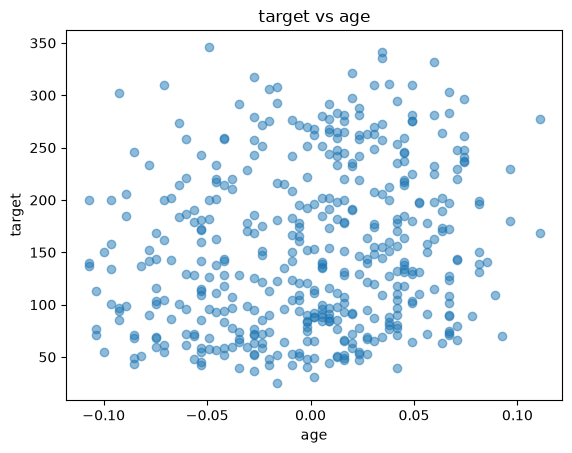

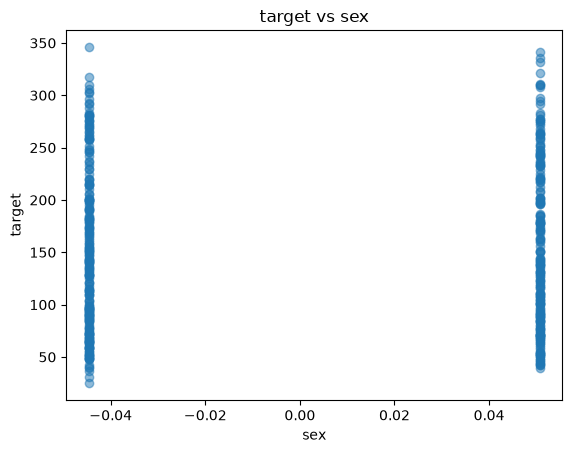

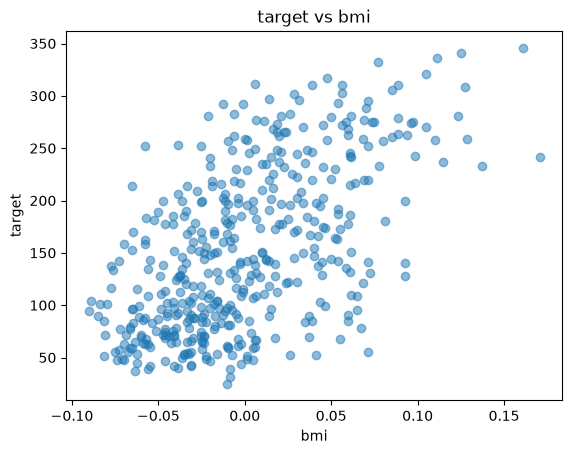

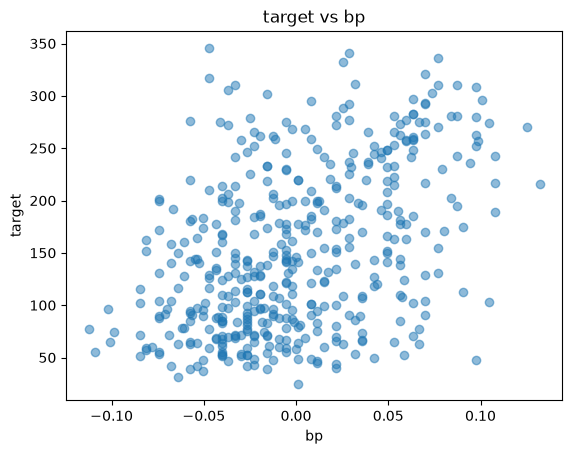

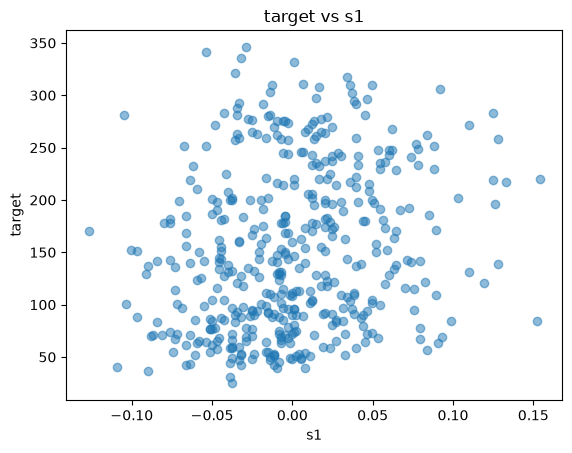

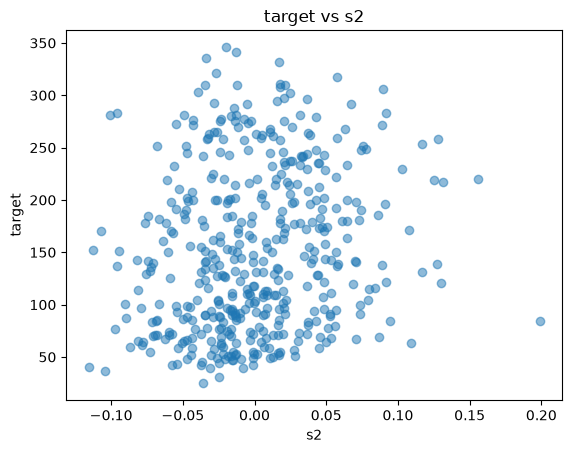

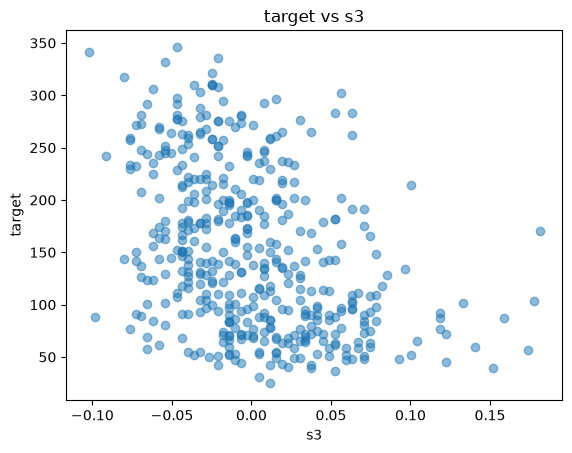

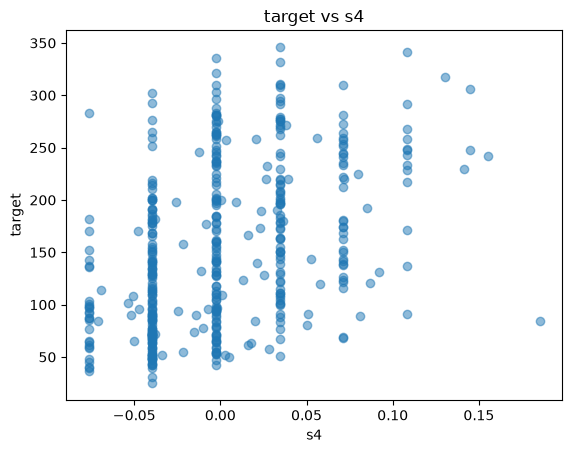

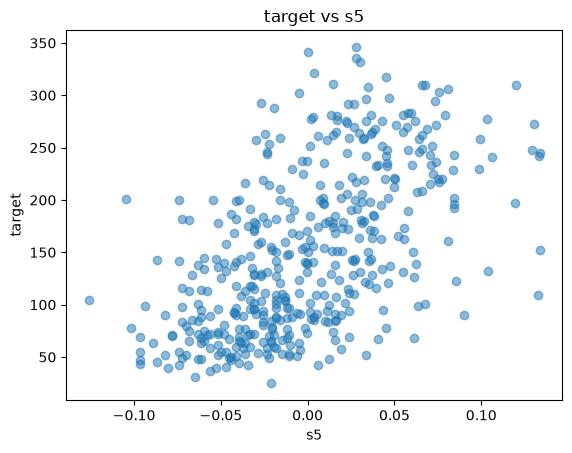

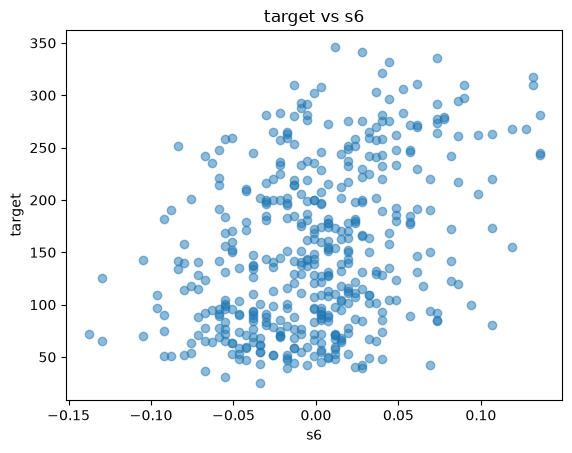

In [14]:
for feature in features:
    plt.scatter(df[feature] , df[required] , alpha=0.5)
    plt.xlabel(feature)
    plt.ylabel(required)
    plt.title(f"{required} vs {feature}")
    plt.show()

In [16]:
x = df[features]
y = df[required]

x_train , x_temp , y_train ,y_temp = train_test_split(x , y , test_size=0.30 , random_state=42)
x_val , x_test , y_val , y_test = train_test_split(x_temp , y_temp ,test_size=0.50, random_state=42)

In [17]:
pipe_linear = Pipeline([
    ("scale" , StandardScaler() ),
    ('model' , LinearRegression()),
])

pipe_linear.fit(x_train , y_train)

y_pred_train = pipe_linear.predict(x_train)
y_val_predict = pipe_linear.predict(x_val)

print(f"error in the y_val: {np.sqrt(mean_squared_error(y_val , y_val_predict)):.4f}")
print(f"error in the y_train: {np.sqrt(mean_squared_error(y_train , y_pred_train)):.4f}")

error in the y_val: 49.9932
error in the y_train: 54.0745


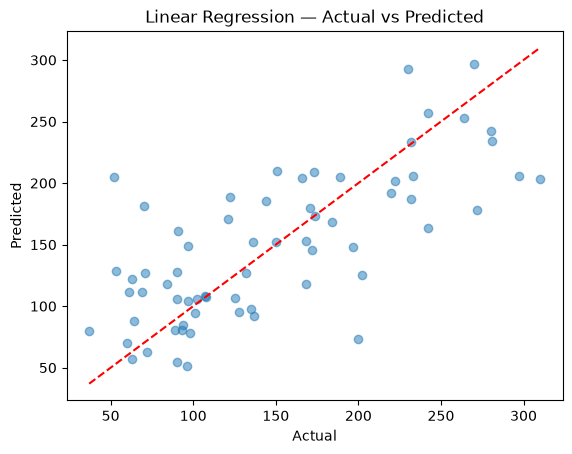

In [18]:
plt.scatter(y_val, y_val_predict, alpha=0.5)
plt.plot([y_val.min(), y_val.max()],
         [y_val.min(), y_val.max()], 'r--')  
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Linear Regression — Actual vs Predicted')
plt.show()

In [28]:
pipe_ridge = Pipeline([
    ("scale" , StandardScaler() ),
    ('model' , Ridge(alpha=1)),
])

pipe_ridge.fit(x_train , y_train)

y_pred_train = pipe_ridge.predict(x_train)
y_val_predict = pipe_ridge.predict(x_val)

print(f"error in the y_val: {np.sqrt(mean_squared_error(y_val , y_val_predict)):.4f}")
print(f"error in the y_train: {np.sqrt(mean_squared_error(y_train , y_pred_train)):.4f}")

error in the y_val: 49.7950
error in the y_train: 54.0924


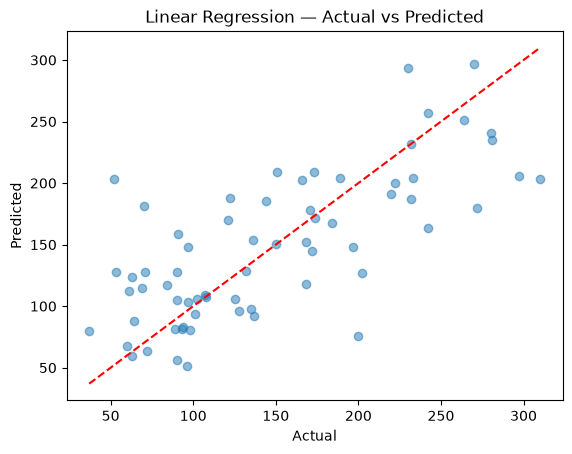

In [29]:
plt.scatter(y_val, y_val_predict, alpha=0.5)
plt.plot([y_val.min(), y_val.max()],
         [y_val.min(), y_val.max()], 'r--')  
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Linear Regression — Actual vs Predicted')
plt.show()

In [ ]:
pipe_poly = Pipeline([
        ("scale" , StandardScaler()),
        ("poly" , PolynomialFeatures(degree=2 , include_bias=False)),
        ("model" , Ridge(alpha=100))
    ])

pipe_poly.fit(x_train , y_train)

y_pred_poly_train = pipe_poly.predict(x_train)
y_pred_poly_value = pipe_poly.predict(x_val)


print(f'Train RMSE : {np.sqrt(mean_squared_error(y_train, y_pred_poly_train)):.4f}')
print(f'Val   RMSE : {np.sqrt(mean_squared_error(y_val,   y_pred_poly_value)):.4f}')


Train RMSE : 51.9379
Val   RMSE : 49.5166


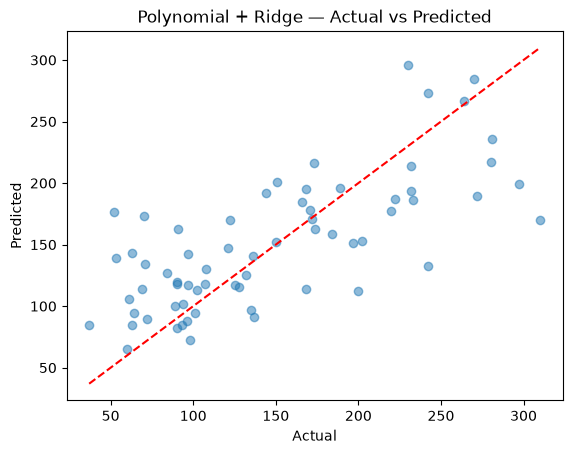

In [39]:
plt.scatter(y_val, y_pred_poly_value, alpha=0.5)
plt.plot([y_val.min(), y_val.max()],
         [y_val.min(), y_val.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Polynomial + Ridge — Actual vs Predicted')
plt.show()

In [41]:
test_error = np.sqrt(mean_squared_error(y_test , pipe_poly.predict(x_test)))
print(f"Total error in the final test : {test_error:.4f}")

Total error in the final test : 55.6120
